# Lag-CRP

> Compute and visualize lag-conditional response probability for free-recall data.

The lag-conditional response probability (Lag-CRP) measures how the probability of recalling an item depends on its serial lag from the previously recalled item. Serial lag is defined as the difference in study positions: if the previous recall was studied at position $X$ and the current recall at position $Y$, then lag $\ell = Y - X$. Negative lags indicate backward transitions in study order; positive lags indicate forward transitions.

$$\text{CRP}(\ell) = \frac{\text{actual transitions at lag } \ell}{\text{available transitions at lag } \ell}$$

CRP curves that peak near $\pm 1$ (often with a forward asymmetry) reveal temporal contiguity: a tendency to transition between items studied near each other in time [@kahana1996associative].

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.crp import (
    crp,
    plot_crp,
    set_false_at_index,
    simple_crp,
    simple_tabulate_trial,
    SimpleTabulation,
    Tabulation,
    tabulate_trial,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "CRP"
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

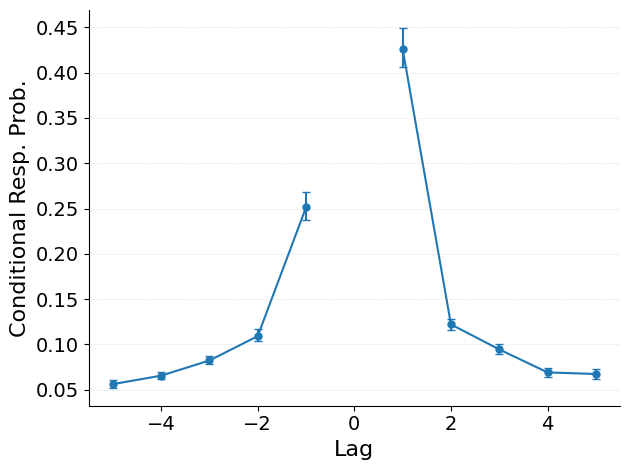

In [5]:
#| code-summary: Plot Lag-CRP
#| label: fig-crp
#| fig-cap: "Lag-CRP showing conditional response probability by serial lag."
plot_crp(data, trial_mask)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

Each dataset is paired with its corresponding mask by index. To compare conditions within one dataset, pass the dataset multiple times with different masks: `plot_crp([data, data], [mask_a, mask_b], ...)`.

In [6]:
#| echo: false
show_doc(plot_crp)

---

### plot_crp

>      plot_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcmr.typ
>                ing.RecallDataset], trial_masks:Union[Sequence[jaxtyping.Bool[A
>                rray,'trial_count']],jaxtyping.Bool[Array,'trial_count']],
>                max_lag:int=5, color_cycle:Optional[list[str]]=None,
>                labels:Optional[Sequence[str]]=None,
>                contrast_name:Optional[str]=None,
>                axis:Optional[matplotlib.axes._axes.Axes]=None, size:int=3,
>                confidence_level:float=0.95)

*Plot subject-wise Lag-CRP with confidence intervals.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| max_lag | int | 5 | Maximum lag to display. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| size | int | 3 | Max study positions an item can occupy. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the Lag-CRP plot.** |

The `plot_crp` function uses `crp` internally, which handles datasets where items may appear at multiple study positions. For lists with no repeated items, `simple_crp` provides a simpler interface that operates directly on serial-position-coded recall arrays.

In [7]:
#| echo: false
show_doc(crp)

---

### crp

>      crp (dataset:jaxcmr.typing.RecallDataset, size:int=3)

*Compute Lag-CRP with support for repeated items.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Float[Array, 'lags']** |  | **CRP of length 2*L - 1; NaN where denominator is<br>zero.** |

In [8]:
# Repeated recalls do not alter the CRP
trials_with_repeat = jnp.array([[2, 3, 2, 4]], dtype=jnp.int32)
trials_without_repeat = jnp.array([[2, 3, 4, 0]], dtype=jnp.int32)
presentations = jnp.array([[1, 2, 3, 4]], dtype=jnp.int32)

def _make_dataset(recalls, presentations):
    n_trials = recalls.shape[0]
    list_length = presentations.shape[1]
    return {
        "subject": jnp.ones((n_trials, 1), dtype=jnp.int32),
        "listLength": jnp.full((n_trials, 1), list_length, dtype=jnp.int32),
        "pres_itemnos": presentations,
        "recalls": recalls,
    }

with_repeat = crp(_make_dataset(trials_with_repeat, presentations), size=1)
without_repeat = crp(_make_dataset(trials_without_repeat, presentations), size=1)
assert jnp.allclose(with_repeat, without_repeat, equal_nan=True)

In [9]:
#| echo: false
show_doc(simple_crp)

---

### simple_crp

>      simple_crp (trials:jaxtyping.Integer[Array,'trialsrecall_events'],
>                  list_length:int)

*Compute Lag-CRP across multiple no-repeat trials.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| trials | Integer[Array, 'trials recall_events'] | Serial positions in 1..L with 0 pads. |
| list_length | int | Study-list length. |
| **Returns** | **Float[Array, 'lags']** | **CRP of length 2*L - 1, indexed by lag offset.** |

In [10]:
# Simple and full tabulators agree when there are no repeats
trials = jnp.array([[1, 2, 3], [1, 3, 2]], dtype=jnp.int32)
presentations = jnp.array([[1, 2, 3], [1, 2, 3]], dtype=jnp.int32)

simple_result = simple_crp(trials, list_length=3)
full_result = crp(_make_dataset(trials, presentations), size=1)
assert jnp.allclose(simple_result, full_result, equal_nan=True)

### Tabulators

The CRP functions above aggregate trial-level tabulations. `tabulate_trial` handles a single trial with repeated items; `simple_tabulate_trial` handles the no-repeat case. Both accumulate actual and available lag transitions across recall events.

In [11]:
#| echo: false
show_doc(tabulate_trial)

---

### tabulate_trial

>      tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                      presentation:jaxtyping.Integer[Array,'study_events'],
>                      size:int=3)

*Tabulate actual and available lags for a single trial.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| trial | Integer[Array, 'recall_events'] |  | Serial positions in 1..L with 0 pads. |
| presentation | Integer[Array, 'study_events'] |  | Item IDs at each study position. |
| size | int | 3 | Max study positions per item. |
| **Returns** | **tuple** |  | **Actual and available lag counts.** |

In [12]:
# Zero-padded recalls are ignored
trial = jnp.array([1, 0, 2, 0, 3], dtype=jnp.int32)
presentation = jnp.array([1, 2, 3], dtype=jnp.int32)
actual, _ = tabulate_trial(trial, presentation, size=1)
assert jnp.sum(actual).item() == 2

In [13]:
#| echo: false
show_doc(simple_tabulate_trial)

---

### simple_tabulate_trial

>      simple_tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                             list_length:int)

*Tabulate lag transitions for a single no-repeat trial.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| trial | Integer[Array, 'recall_events'] | Serial positions in 1..L with 0 pads. |
| list_length | int | Study-list length. |
| **Returns** | **SimpleTabulation** | **Accumulated actual and available transitions.** |

In [14]:
# Both tabulators count the same number of transitions
trial = jnp.array([1, 2, 3], dtype=jnp.int32)
presentation = jnp.array([1, 2, 3], dtype=jnp.int32)

simple = simple_tabulate_trial(trial, list_length=3)
simple_count = jnp.sum(simple.actual_transitions).item()
full_actual, _ = tabulate_trial(trial, presentation, size=1)
full_count = jnp.sum(full_actual).item()

assert simple_count == 2
assert full_count == 2
assert simple_count == full_count

### Utilities

In [15]:
#| echo: false
show_doc(set_false_at_index)

---

### set_false_at_index

>      set_false_at_index (vec:jaxtyping.Bool[Array,'positions'],
>                          i:jaxtyping.Integer[Array,'']|int)

*Set ``vec[i - 1]`` to ``False`` using 1-based indexing.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| vec | Bool[Array, 'positions'] | Boolean vector. |
| i | jaxtyping.Integer[Array, ''] \| int | 1-based index; 0 is a no-op sentinel. |
| **Returns** | **tuple** | **Updated vector and ``None``.** |

In [16]:
# 1-based indexing: index 3 clears position 2 (0-based)
vec = jnp.array([True, True, True, True], dtype=bool)
updated, _ = set_false_at_index(vec, 3)
assert updated.tolist() == [True, True, False, True]

# Index 0 is a no-op sentinel
unchanged, _ = set_false_at_index(vec, 0)
assert unchanged.tolist() == [True, True, True, True]